# Input Analysis (IE 306 Principles)

This notebook covers the standard workflow from the IE 306 course for fitting and validating statistical distributions from historical data.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load Data & Compute Descriptive Statistics

In [10]:
# Load Kadikoy Arrivals
try:
    df = pd.read_csv('arrivals_kadikoy.csv')
    df['dt'] = pd.to_datetime(df['date'] + ' ' + df['time'])
    df = df.sort_values('dt')
    df['inter_arrival'] = df['dt'].diff().dt.total_seconds()
    df = df.dropna()
    
    # Remove overnight gaps (e.g. inter-arrivals > 3600 seconds)
    iat = df[df['inter_arrival'] < 1800]['inter_arrival'].values
    print("Mean:", np.mean(iat))
    print("Std:", np.std(iat))
    print("CV:", np.std(iat) / np.mean(iat))
except FileNotFoundError:
    print("Data not found, please ensure 'arrivals_kadikoy.csv' exists.")

Mean: 4.37450200573018
Std: 6.034331914737396
CV: 1.3794328832934575


## 2. Goodness-of-Fit and Plotting

KS Test (Exponential): Statistic=0.0796, p-value=0.0000e+00
Reject Null: Data does not follow Exponential distribution.


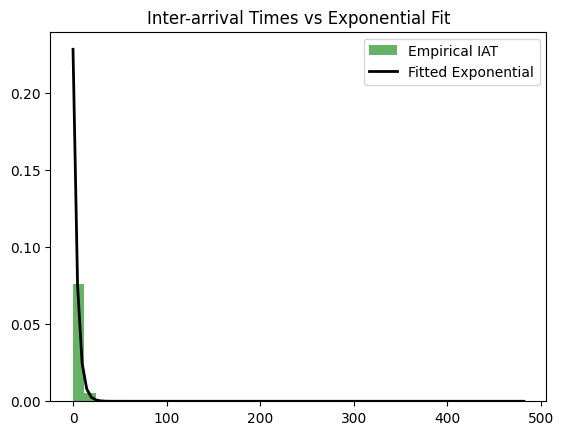

In [11]:
if 'iat' in locals():
    # Fit Exponential
    loc, scale = stats.expon.fit(iat)
    
    # KS Test for Exponential
    D, p_value = stats.kstest(iat, 'expon', args=(loc, scale))
    print(f"KS Test (Exponential): Statistic={D:.4f}, p-value={p_value:.4e}")
    
    if p_value < 0.05:
        print("Reject Null: Data does not follow Exponential distribution.")
    else:
        print("Fail to Reject Null: Data matches Exponential distribution.")
    
    # Histogram vs Fit
    plt.hist(iat, bins=40, density=True, alpha=0.6, color='g', label='Empirical IAT')
    
    x = np.linspace(0, max(iat), 100)
    p = stats.expon.pdf(x, loc, scale)
    plt.plot(x, p, 'k', linewidth=2, label='Fitted Exponential')
    plt.title('Inter-arrival Times vs Exponential Fit')
    plt.legend()
    plt.show()
    

## 3. Q-Q Plot Validation

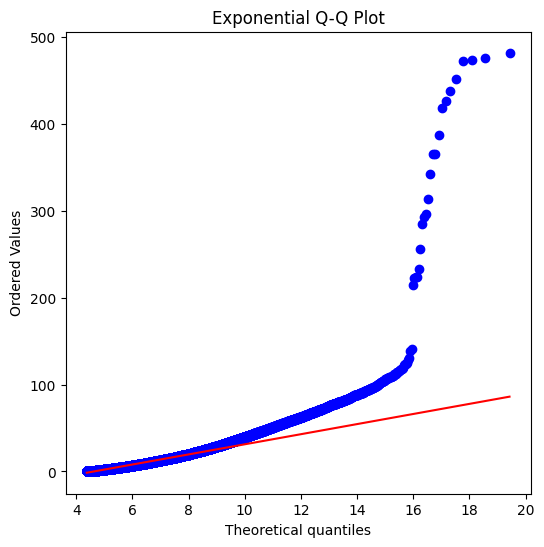

In [12]:
if 'iat' in locals():
    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(iat, dist="expon", sparams=(scale,), plot=ax)
    ax.set_title("Exponential Q-Q Plot")
    plt.show()